# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# завантажити
df = pd.read_csv("../data/House_Rent_Dataset.csv")

In [3]:
# розмір
df.shape

(4746, 12)

In [4]:
# хед
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [5]:
# заг інф
df.info


<bound method DataFrame.info of        Posted On  BHK   Rent  Size            Floor    Area Type  \
0     2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1     2022-05-13    2  20000   800       1 out of 3   Super Area   
2     2022-05-16    2  17000  1000       1 out of 3   Super Area   
3     2022-07-04    2  10000   800       1 out of 2   Super Area   
4     2022-05-09    2   7500   850       1 out of 2  Carpet Area   
...          ...  ...    ...   ...              ...          ...   
4741  2022-05-18    2  15000  1000       3 out of 5  Carpet Area   
4742  2022-05-15    3  29000  2000       1 out of 4   Super Area   
4743  2022-07-10    3  35000  1750       3 out of 5  Carpet Area   
4744  2022-07-06    3  45000  1500     23 out of 34  Carpet Area   
4745  2022-05-04    2  15000  1000       4 out of 5  Carpet Area   

                 Area Locality       City Furnishing Status  Tenant Preferred  \
0                       Bandel    Kolkata       Unfurnished  Bachelors

## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [6]:
# Аналіз пропущених значень
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) *100
missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

не виявили пропусків даних, тому очищення чи видалення рядків не потребуємо

In [7]:
# Базова статистика

stats = df.describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


статистика показує 

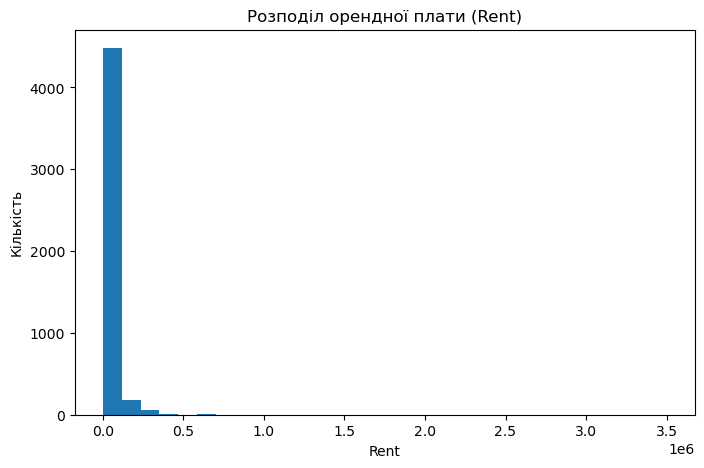

In [8]:
# Аналіз цільової змінної Rent

plt.figure(figsize=(8,5))
df["Rent"].plot(kind="hist", bins=30)

plt.title("Розподіл орендної плати (Rent)")
plt.xlabel("Rent")
plt.ylabel("Кількість")
plt.show()

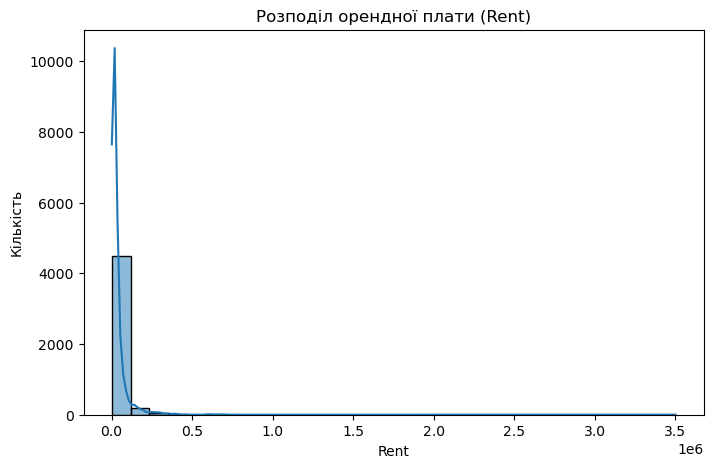

In [9]:
# або

plt.figure(figsize=(8, 5))
sns.histplot(df["Rent"], bins=30, kde=True)

plt.title("Розподіл орендної плати (Rent)")
plt.xlabel("Rent")
plt.ylabel("Кількість")
plt.show()

Ми отримали сильно скошений вправо розподіл - більшість значень потрапляють в діапазон низької оренди, але є невелика кількість дорогих обʼєктів (наші викиди). Тож нам знадобиться додаткова обробка даних.

In [10]:
# Робота з викидами
# межі

Q1 = df["Rent"].quantile(0.25)  # 25% даних дешевші за це значення
Q3 = df["Rent"].quantile(0.75)  # 75% даних дешевші за це значення
IQR = Q3 - Q1                   # основна маса

# межі нормальних значень
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"lower_bound = {lower_bound}, upper_bound = {upper_bound}")

lower_bound = -24500.0, upper_bound = 67500.0


In [11]:
# фільтруємо, видаляємо викиди

df_clean = df[(df["Rent"] >= lower_bound) & (df["Rent"] <= upper_bound)].copy()

In [12]:
# перевірка

df.shape, df_clean.shape

((4746, 12), (4226, 12))

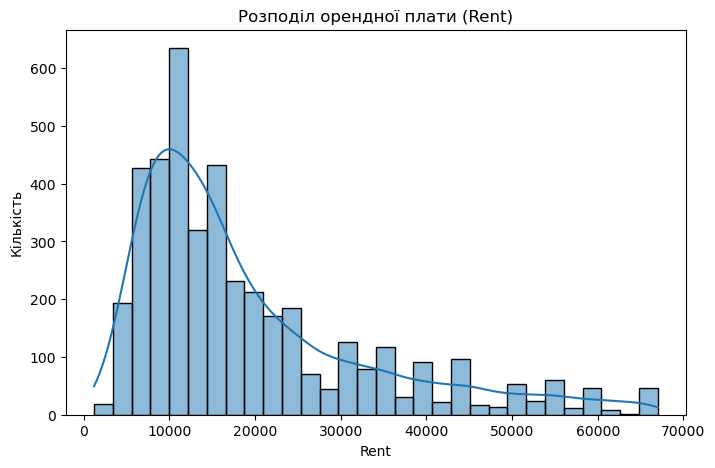

In [13]:
# новий шрафік

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Rent"], bins=30, kde=True)

plt.title("Розподіл орендної плати (Rent)")
plt.xlabel("Rent")
plt.ylabel("Кількість")
plt.show()

IQR — основна маса. Значення які виходять за нижню та верхню границі були видалені.

Ми залишили тільки адекватні значення Rent (видалили близько 520рядків)

Ми також отримали lower_bound = -24500, але рента не може бути відємною, тому нам важлива саме верхня межа upper_bound = 67500 - все що вище цього значення буде відкинуто.

Так ми зробили дані приатними для подальшого аналіізу.


In [14]:
# створюєм нову колонку, де великі значення стиснуті
# log1p(x) = log(1 + x) безпечніше, навіть якщо раптом трапиться 0.

df_clean["log_Rent"] = np.log1p(df_clean["Rent"])

In [15]:
df_clean.describe().round(2)

,BHK,Rent,Size,Bathroom,log_Rent
count,4226.00,4226.00,4226.00,4226.00,4226.00
mean,1.96,19286.16,871.78,1.81,9.64
std,0.75,13825.40,485.78,0.71,0.66
min,1.00,1200.00,10.00,1.00,7.09
25%,1.00,9500.00,520.00,1.00,9.16
50%,2.00,15000.00,800.00,2.00,9.62
75%,2.00,25000.00,1100.00,2.00,10.13
max,6.00,67000.00,4200.00,7.00,11.11


Застосування логарифмування дозволяє зменшити асиметрію розподілу, та вплив великих значень. Це покращить якість лінійної можелі

До очищення було:

Rent max = 3 500 000
mean ≈ 34 993

Після:

Rent max = 67 000
mean ≈ 19 286
median = 15 000

Без екстремальних значень, навчаємо модель саме на типових спостереженнях

In [16]:
# Аналіз категоріальних змінних

category_columns = df_clean.select_dtypes(include="object").columns
df_clean[category_columns].nunique().sort_values(ascending=False)


Area Locality        1997
Floor                 340
Posted On              80
City                    6
Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64

Area Locality, Floor та дату відкидаємо, інші колонки перетворюємо:

In [17]:
category_columns = ["City", "Area Type", "Furnishing Status",  "Tenant Preferred", "Point of Contact"]

In [18]:
df_encoded = pd.get_dummies(df_clean, columns=category_columns, drop_first=True)

До моделі включили лише ті змінні, які мають невелику кількість унікальних значень (City, Area Type, Furnishing Status, Tenant Preferred, Point of Contact), Інші відкинули


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [19]:
# матриця кореляцій

numbers_df = df_clean.select_dtypes(include=["number"])   # взяти числа

correlation_matrix = numbers_df.corr().round(3)                      
correlation_matrix

,BHK,Rent,Size,Bathroom,log_Rent
BHK,1.000,0.401,0.698,0.748,0.465
Rent,0.401,1.000,0.394,0.507,0.937
Size,0.698,0.394,1.000,0.681,0.447
Bathroom,0.748,0.507,0.681,1.000,0.561
log_Rent,0.465,0.937,0.447,0.561,1.000


In [20]:
# кореляційнa матриця - heatmap

fig = px.imshow(
    correlation_matrix,
    text_auto = ".2f",
    color_continuous_scale= "RdBu_r",
    title = "Кореляційна матриця",
    labels = dict(color = "Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [21]:
# Інтерпретація кореляції

# 0.7-1.0 — сильна позитивна кореляція
# 0.3-0.7 — помірна позитивна кореляція
# -0.3-0.3 — слабка або відсутня кореляція
# -0.7--0.3 — помірна негативна кореляція
# -1.0--0.7 — сильна негативна кореляція

Як видно, ми маємо:

сидьну кореляцію 

0.75 між BHK та Bathroom, 

і 0.7 між BHK та Size.

та досить сильну позитивну кореляцію 0.68 між Size та Bathroom.

помірно позитивну 

0.51 між Bathroom та Rent,

0.4 між BHK та Rent

0.39 між Size та Rent

Загалом, між змінними BHK, Size та Bathroom спостерігаємо високу кореляцію, це потребує подальшої уваги.

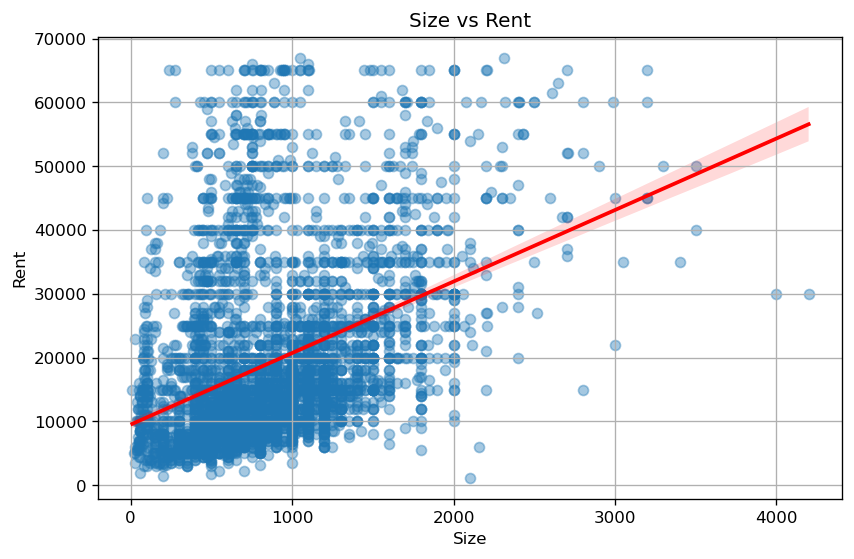

In [22]:
# scatter plot між Size та Rent

plt.figure(figsize=(8, 5), dpi = 120)

sns.regplot(
    data = df_clean, 
    x= "Size", 
    y= "Rent", 
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Size vs Rent")
plt.xlabel("Size")
plt.ylabel("Rent")
plt.grid("True")

plt.show()

лінія тренду вказує позитивну залежність між Size та Rent.
Зі збільшенням площі зростає і вартість оренди.
Видно також що для більших площ наявний і більший розкид значень, це свідчить про вплив інших факторів, наприклад локації


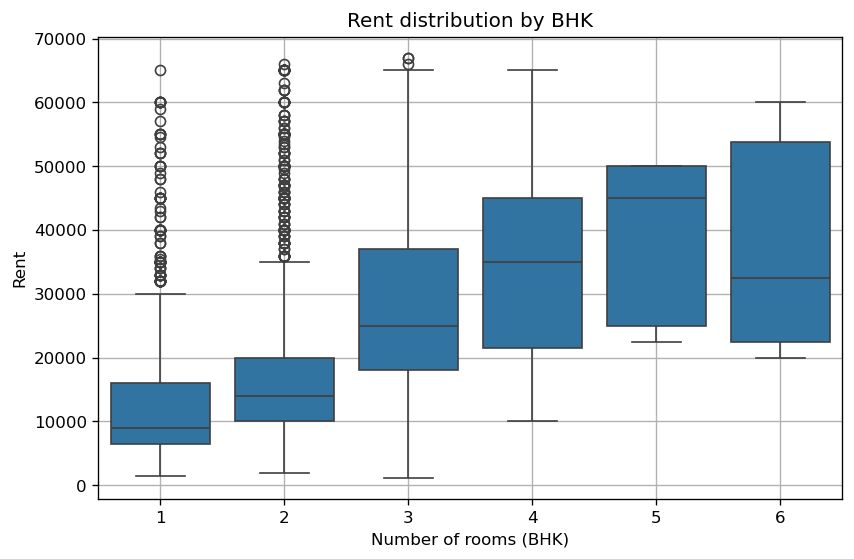

In [23]:
# взаємозв'язок між BHK та Rent за допомогою boxplot

plt.figure(figsize=(8, 5), dpi = 120)

sns.boxplot(
    data = df_clean.sort_values("BHK"),
    x = "BHK",
    y = "Rent"
)

plt.title("Rent distribution by BHK")
plt.xlabel("Number of rooms (BHK)")
plt.ylabel("Rent")
plt.grid(True)

plt.show()

Boxplot показує чіткий позитивний зв’язок між кількістю кімнат та орендною платою. Зі збільшенням ВНК зростає і оренда, збільшується розкид цін - більша квартира, більша варіативність ціни. Для маленьких квартир спостерігаємо багато викидів - трапляються дорогі варіанти навіть з малими площами.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [24]:
# One-Hot Encoding

category_columns = df_clean.select_dtypes(include="object").columns

df_clean[category_columns].nunique().sort_values(ascending=False)

Area Locality        1997
Floor                 340
Posted On              80
City                    6
Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64

In [25]:
category_columns  = ["City", "Area Type", "Furnishing Status", "Tenant Preferred", "Point of Contact"]

df_model = pd.get_dummies(df_clean, columns=category_columns, drop_first=True)

In [26]:
# не берем в модель\видаляєм

drop_columns = ["Posted On", "Area Locality", "Floor"]

До моделі включили лише ті змінні, які мають невелику кількість унікальних значень (City, Area Type, Furnishing Status, Tenant Preferred, Point of Contact), для них застосовано One-Hot Encoding, Інші відкинули

In [27]:
# ділимо дані на ознаки (X) та цільову змінну (y)

# цільова змінна: що будемо прогнозувати
y = df_model["log_Rent"]

# ознаки:    на основі чого будемо прогнозувати 
X = df_model.drop(columns=["Rent", "log_Rent"] + drop_columns)

In [28]:
# стандартизація:

num_columns = X.select_dtypes(include=["int64", "float64"]).columns

In [29]:
X.shape, y.shape

((4226, 16), (4226,))

In [30]:
X.head()

,BHK,Size,Bathroom,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,2,1100,2,False,False,False,True,False,False,True,False,True,True,False,False,True
1,2,800,1,False,False,False,True,False,False,True,True,False,True,False,False,True
2,2,1000,1,False,False,False,True,False,False,True,True,False,True,False,False,True
3,2,800,1,False,False,False,True,False,False,True,False,True,True,False,False,True
4,2,850,1,False,False,False,True,False,True,False,False,True,False,False,False,True


зробимо стандартизацію після train/test split (нижче) аби навчання відбулось лише на тренувальних даних

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)